# 数据预处理

In [ ]:
# 打开并读取莎士比亚文本文件，使用utf-8编码以保证兼容所有字符
with open('shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()  # 读取全部文本内容到变量text

# 打印文本的总长度（字符数）
print(f"文本长度: {len(text)}")
# 打印文本的前100个字符，便于了解数据格式

print(f"文本前100个字符:\n{text[:100]}")

# 获取文本中所有不同的字符，并将其排序，形成一个有序的字符列表
chars = sorted(list(set(text)))

# 创建字符到索引的映射字典。enumerate为每个字符分配一个独特的数字ID（从0开始）
char2idx = {ch: idx for idx, ch in enumerate(chars)}
# 创建索引到字符的映射字典，用于后续还原生成文本
idx2char = {idx: ch for idx, ch in enumerate(chars)}

# 打印总共包含的字符种类数
print(f"Total chars: {len(chars)}")
# 示例：打印char2idx映射字典中的前10项，查看部分字符和对应的编号
print(f"Example char2idx: {list(char2idx.items())[:10]}")
# 示例：打印idx2char映射字典中的前10项，查看部分编号和对应字符
print(f"Example idx2char: {list(idx2char.items())[:10]}")


文本长度: 1115394
文本前100个字符:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You
Total chars: 65
Example char2idx: [('\n', 0), (' ', 1), ('!', 2), ('$', 3), ('&', 4), ("'", 5), (',', 6), ('-', 7), ('.', 8), ('3', 9)]
Example idx2char: [(0, '\n'), (1, ' '), (2, '!'), (3, '$'), (4, '&'), (5, "'"), (6, ','), (7, '-'), (8, '.'), (9, '3')]


In [2]:
# 将文本转换为数字序列
import numpy as np
text_as_int = np.array([char2idx[c] for c in text]) #把全部文本都变为id
print(len(text_as_int))
text_as_int[:20]

1115394


array([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43,
       44, 53, 56])

In [ ]:
# ===============================
# 导入必要的库
import torch
from torch.utils.data import Dataset, DataLoader

# 设置序列长度和批次大小
seq_length = 100  # 每个输入样本包含的字符数（用于训练，决定模型能利用多少上下文）
batch_size = 64   # 每个批次（batch）包含的样本数量（影响GPU利用率和训练速度）

# ===============================
# 创建自定义数据集类，用于构建顺序字符数据对用于下一个字符预测任务
class ShakespeareDataset(Dataset):
    def __init__(self, text_as_int, seq_length):
        """
        初始化数据集对象
        
        参数
        -------
        text_as_int : np.ndarray 或 List[int]
            整个莎士比亚文本的数字编码表示
        seq_length : int
            每一个序列样本的长度
        """
        self.text_as_int = text_as_int
        self.seq_length = seq_length
        self.sub_len = seq_length + 1 # 一个样本含有一个input序列和一个label，label比input向后移一位

    def __len__(self):
        """
        返回数据集中有多少个样本
        """
        # 用总长度整除样本长度（+1，保证label可取），得到可切分的样本数
        return len(self.text_as_int) // self.sub_len

    def __getitem__(self, idx):
        """
        获取数据集中第idx个样本
        
        参数
        -------
        idx : int
            样本的索引
            
        返回
        -------
        torch.Tensor
            长度为seq_length+1的数字id张量（long类型），后续拆分为input和target
        """
        # 按序号获取一段连续的文本（数字编码），并转换为torch long类型张量
        start_idx = idx * self.sub_len
        end_idx = (idx + 1) * self.sub_len
        sample = self.text_as_int[start_idx:end_idx]
        return torch.tensor(sample, dtype=torch.long)

# ===============================
# 定义批处理辅助函数（collate_fn），将列表形式的样本转换为批量训练所需的格式
def collate_fct(batch):
    """
    将输入的单个样本列表组合为批量张量，并切分成input和target
    
    参数
    -------
    batch : List[Tensor]
        每个元素都是长度为(seq_length+1)的1D tensor

    返回
    -------
    input_batch : Tensor
        形状为 [batch_size, seq_length]，输入序列
    target_batch : Tensor
        形状为 [batch_size, seq_length]，每个输入序列对应的下一个字符
    """
    # 堆叠列表中的每个样本，得到 [batch_size, seq_length+1] 的张量
    batch = torch.stack(batch)
    # input是前seq_length个字符
    input_batch = batch[:, :-1]
    # target是后seq_length个字符（即input的下一个字符）
    target_batch = batch[:, 1:]
    return input_batch, target_batch

# ===============================
# 构建自定义莎士比亚数据集实例
shakespeare_dataset = ShakespeareDataset(text_as_int, seq_length)

# 构建DataLoader：提供批量数据加载、打乱(shuffle)、丢弃不满的batch(drop_last)、和自定义collate功能
dataloader = DataLoader(
    shakespeare_dataset,
    batch_size=batch_size,
    shuffle=True,         # 打乱样本，提高泛化性
    drop_last=True,       # 丢弃最后不满一个完整batch的部分
    collate_fn=collate_fct
)

# ===============================
# 打印一个批次（示例）来检查输入输出
for input_batch, target_batch in dataloader:
    print(f"输入批次形状: {input_batch.shape}")      # 应为 [batch_size, seq_length]
    print(f"目标批次形状: {target_batch.shape}")    # 应为 [batch_size, seq_length]
    # 打印该批次第一个样本的input和target（都是张量）
    print("第一个样本input:", input_batch[0])
    print("第一个样本target:", target_batch[0])
    break  # 只检查第一个batch即停止（不必全部打印）

# 打印整个数据集样本数和loader中的批次数量，确认合理
print(f"\n数据集大小: {len(shakespeare_dataset)}")          # 样本总数
print(f"批次数量: {len(dataloader)}")                      # 总批次数


输入批次形状: torch.Size([64, 100])
目标批次形状: torch.Size([64, 100])
tensor([[56,  1, 58,  ..., 43, 56,  1],
        [39, 56, 58,  ..., 46, 43, 50],
        [43, 56, 63,  ..., 40, 43,  1],
        ...,
        [59, 56, 52,  ..., 19, 53, 42],
        [58,  1, 58,  ..., 47, 58,  1],
        [13, 10,  0,  ..., 41, 58, 59]])
tensor([[ 1, 58, 53,  ..., 56,  1, 44],
        [56, 58, 46,  ..., 43, 50, 50],
        [56, 63,  1,  ..., 43,  1, 58],
        ...,
        [56, 52,  1,  ..., 53, 42,  1],
        [ 1, 58, 46,  ..., 58,  1, 58],
        [10,  0, 21,  ..., 58, 59, 56]])

数据集大小: 11043
批次数量: 172


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# 定义莎士比亚文本生成用的RNN模型，基于LSTM结构
class ShakespeareRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, batch_size):
        """
        参数说明：
        vocab_size : int
            词汇的总数量，即字符表的大小
        embedding_dim : int
            嵌入层的维度，将每个int索引的字符映射为此维度的向量
        hidden_dim : int
            RNN隐藏状态的维度
        batch_size : int
            批次大小（注：本实现中该参数未直接用到，但可为后续扩展做准备）
        """
        super().__init__()
        # 嵌入层：将整数索引转换为embedding向量
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # LSTM层：单层、非双向、输入批处理的第一个维度(batch_first=True)
        self.rnn = nn.LSTM(
            embedding_dim,      # 输入特征维度，等于embedding_dim
            hidden_dim,         # 隐藏状态维度
            num_layers=1,       # LSTM堆叠层数为1
            bidirectional=False,# 非双向
            batch_first=True    # 输入和输出shape为[batch, seq, feature]
        )

        # 全连接层：把LSTM输出映射到词表大小，即输出每个时间步每个字符的概率分布
        self.dense = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, hidden=None):
        """
        前向传播函数

        参数：
        x : Tensor
            输入，形状为[batch_size, sequence_length]，每个元素是字符索引
        hidden : Tuple[Tensor, Tensor] or None
            隐状态(h, c)，可选，用于序列连续生成

        返回：
        output : Tensor
            经过全连接后的输出，[batch_size, sequence_length, vocab_size]
        hidden : Tuple[Tensor, Tensor]
            LSTM的隐状态（h, c），可用于下次输入
        """

        # hidden参数用于传递LSTM的“隐状态”(hidden state)和“细胞状态”(cell state)。
        # 在RNN/LSTM中，每当处理完一个序列（如一段文本/一个批次）时，LSTM会输出一组新的隐状态和细胞状态：
        #   - 隐状态(h)：保存了序列当前累计的“记忆”信息，影响下一个时间步的输出
        #   - 细胞状态(c)：长期存储记忆信息，决定模型能记住多久
        # 如果在生成文本或训练长序列时，想让模型“记住”前面所有内容，就需要把前一次的(hidden)作为下一次输入。
        # 如果不传hidden，则LSTM默认将其初始化为全0，即认为是新的一段，不继承之前的上下文。
        # 1. 嵌入：将输入索引映射为向量 [batch_size, sequence_length, embedding_dim]
        x = self.embedding(x)

        # 2. LSTM：输出output为所有时间步的隐藏状态，hidden为最后的(h_n, c_n)
        # output.shape: [batch_size, sequence_length, hidden_dim]
        output, hidden = self.rnn(x, hidden)

        # 3. 全连接解码：预测每个时间步属于各个字符的logits [batch_size, sequence_length, vocab_size]
        output = self.dense(output)
        return output, hidden
    

# ========== 设定模型参数并实例化模型 ==========
vocab_size = len(char2idx)    # 词汇表大小
embedding_dim = 256           # 嵌入层大小（可根据算力调整）
rnn_units = 1024              # RNN隐藏单元数量
# 实例化莎士比亚字符级LSTM模型
model = ShakespeareRNN(vocab_size, embedding_dim, rnn_units, batch_size)
# 输出模型结构信息，检查正确性
print(model)


ShakespeareRNN(
  (embedding): Embedding(65, 256)
  (rnn): LSTM(256, 1024, batch_first=True)
  (dense): Linear(in_features=1024, out_features=65, bias=True)
)


In [5]:
# 编写前向计算验证模型是否ok
sample_input = torch.randint(0, vocab_size, (batch_size, seq_length), dtype=torch.long)
sample_output, (sample_hidden, sample_cell) = model(sample_input)
print("输入 shape:", sample_input.shape)
print("输出 shape:", sample_output.shape)
print("隐藏状态 shape:", sample_hidden.shape)
print("细胞状态 shape:", sample_cell.shape)


输入 shape: torch.Size([64, 100])
输出 shape: torch.Size([64, 100, 65])
隐藏状态 shape: torch.Size([1, 64, 1024])
细胞状态 shape: torch.Size([1, 64, 1024])


In [6]:
tensor = torch.randn(3, 4)
print(tensor)
tensor_reshaped = tensor.reshape(-1)
print(tensor_reshaped.shape)


tensor([[ 0.2897,  1.4523, -1.9123,  0.5911],
        [ 1.6878,  0.7143, -0.4585,  1.5308],
        [ 0.7594,  0.3737, -0.4936,  0.2109]])
torch.Size([12])


# 训练

In [ ]:
from tqdm.auto import tqdm

# 定义损失函数和优化器
# CrossEntropyLoss用于多分类问题，这里用于字符级别预测
criterion = nn.CrossEntropyLoss()
# Adam优化器，通常在NLP等任务表现良好
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练函数，负责模型的一个完整训练过程
def train_step(model, dataloader, optimizer, criterion, epochs=5):
    losses = []  # 用于记录每个epoch的平均损失

    for epoch in range(epochs):
        model.train()            # 设置模型为训练模式，启用dropout、batchnorm等
        epoch_loss = 0           # 累加当前epoch的损失

        # 使用tqdm包包装dataloader以显示训练进度条
        with tqdm(dataloader, desc=f"轮次 {epoch+1}/{epochs}") as pbar:
            for input_batch, target_batch in pbar:
                # 将输入和目标转移到指定的device（CPU/GPU）
                input_batch = input_batch.to(device)
                target_batch = target_batch.to(device)
                optimizer.zero_grad()  # 每次迭代前清空梯度

                # 前向传播，得到输出
                output, _ = model(input_batch)

                # 将output重塑为二维，[batch_size*seq_len, vocab_size]，以适配CrossEntropyLoss
                # target_batch也需要拉平为一维 [batch_size*seq_len]
                output = output.reshape(-1, vocab_size)
                target_batch = target_batch.reshape(-1)

                # 计算损失
                loss = criterion(output, target_batch)

                # 反向传播，计算梯度
                loss.backward()
                # 更新模型参数
                optimizer.step()

                current_loss = loss.item()       # 获取当前batch的损失值
                epoch_loss += current_loss       # 累加损失值

                # 实时更新进度条显示当前batch的损失
                pbar.set_postfix({"损失": f"{current_loss:.4f}"})

        # 计算并记录当前epoch的平均损失
        avg_epoch_loss = epoch_loss / len(dataloader)
        losses.append(avg_epoch_loss)
        print(f"轮次 {epoch+1}/{epochs} 完成, 平均损失: {avg_epoch_loss:.4f}")

    return losses  # 返回每个epoch的平均损失值，用于后续可视化等

# 判定当前PyTorch可用的设备（优先用GPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 将模型参数以及缓冲区移动到目标设备（CPU或GPU）
model = model.to(device)

# 正式启动训练过程，losses记录每轮平均损失，方便分析
losses = train_step(model, dataloader, optimizer, criterion, epochs=5)

轮次 1/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 1/5 完成, 平均损失: 2.0783


轮次 2/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 2/5 完成, 平均损失: 1.5487


轮次 3/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 3/5 完成, 平均损失: 1.4172


轮次 4/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 4/5 完成, 平均损失: 1.3479


轮次 5/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 5/5 完成, 平均损失: 1.2978


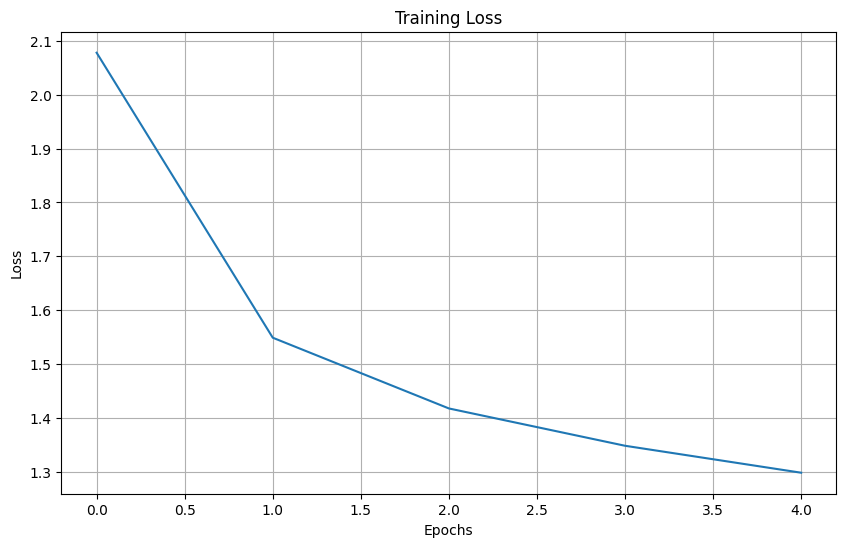

In [8]:
import matplotlib.pyplot as plt
# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 预测

In [9]:
# 理解torch.multinomial函数的小例子
import torch
import torch.nn.functional as F

# 创建一个概率分布
probs = torch.tensor([0.1, 0.2, 0.3, 0.4])
print("概率分布:", probs)

# 从概率分布中采样一个元素
sample = torch.multinomial(probs, num_samples=1)
print("采样一个元素:", sample.item(), "对应概率:", probs[sample.item()].item())

概率分布: tensor([0.1000, 0.2000, 0.3000, 0.4000])
采样一个元素: 3 对应概率: 0.4000000059604645


原始logits值: tensor([1.0000, 2.0000, 5.0000, 3.0000, 0.5000])

temperature=0.5时的概率分布:
tensor([3.2848e-04, 2.4272e-03, 9.7919e-01, 1.7934e-02, 1.2084e-04])

temperature=1.0时的概率分布:
tensor([0.0151, 0.0410, 0.8234, 0.1114, 0.0091])

temperature=2.0时的概率分布:
tensor([0.0739, 0.1218, 0.5459, 0.2008, 0.0575])


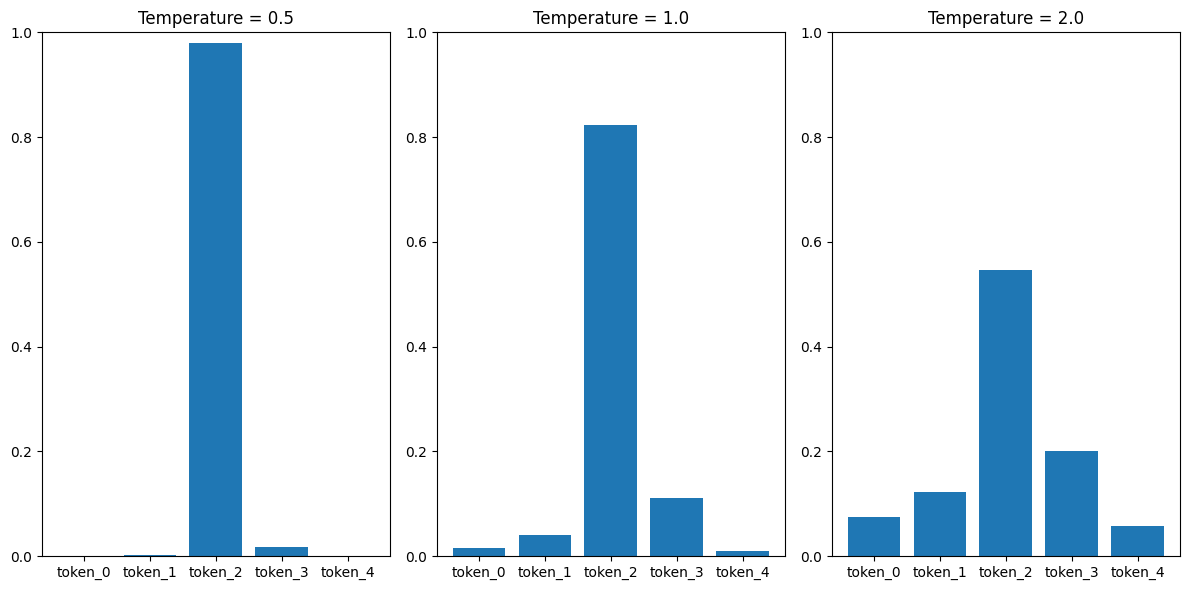


解释:
- 较低的temperature (如0.5) 使概率分布更加尖锐，最高概率的token被选中的可能性更大
- 标准temperature (1.0) 保持原始概率分布
- 较高的temperature (如2.0) 使概率分布更加平坦，增加了采样的随机性


In [10]:
# 展示temperature参数对softmax输出的影响
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 创建一个模拟的logits输出
logits = torch.tensor([1.0, 2.0, 5.0, 3.0, 0.5])
print("原始logits值:", logits)

# 使用不同的temperature值
temperatures = [0.5, 1.0, 2.0]

plt.figure(figsize=(12, 6))

for i, temp in enumerate(temperatures):
    # 应用temperature
    scaled_logits = logits / temp
    
    # 应用softmax获取概率分布
    probabilities = F.softmax(scaled_logits, dim=0)
    
    # 打印结果
    print(f"\ntemperature={temp}时的概率分布:")
    print(probabilities)
    
    # 可视化
    plt.subplot(1, len(temperatures), i+1)
    plt.bar(range(len(probabilities)), probabilities.numpy())
    plt.title(f"Temperature = {temp}")
    plt.ylim(0, 1)
    plt.xticks(range(len(probabilities)), [f"token_{i}" for i in range(len(probabilities))])

plt.tight_layout()
plt.show()

print("\n解释:")
print("- 较低的temperature (如0.5) 使概率分布更加尖锐，最高概率的token被选中的可能性更大")
print("- 标准temperature (1.0) 保持原始概率分布")
print("- 较高的temperature (如2.0) 使概率分布更加平坦，增加了采样的随机性")


# 温度是解码策略之一

In [11]:
# 生成文本函数
def generate_text(model, start_string, char2idx, idx2char, num_generate=1000, temperature=1.0):
    # 将模型设置为评估模式
    model.eval()
    
    # 将起始字符串转换为索引
    input_indices = [char2idx[char] for char in start_string]
    input_tensor = torch.tensor(input_indices, dtype=torch.long).unsqueeze(0).to(device) #unsqueeze(0) 在第0维上增加一个维度
    print(input_tensor.shape) #(1,5)
    # 存储生成的文本
    generated_text = start_string
    
    # 隐藏状态初始化为None，模型会自动初始化
    hidden = None
    
    # 生成指定数量的字符
    with torch.no_grad():
        for _ in range(num_generate):
            # 获取模型预测
            output, hidden = model(input_tensor,hidden)
            
            # 应用温度参数调整预测分布
            logits = output[:, -1, :] / temperature
            
            # 从调整后的分布中采样下一个字符
            probabilities = F.softmax(logits, dim=-1)
            predicted_id = torch.multinomial(probabilities, 1) #从概率分布中采样一个元素，概率越大，被选中的可能性越大
            
            # 将预测的字符添加到生成文本中
            generated_char = idx2char[predicted_id.item()]
            generated_text += generated_char #放入到生成序列
            
            # 更新输入张量为当前预测的字符
            input_tensor = predicted_id
    
    return generated_text

generate_text(model, 'hello',char2idx,idx2char)

torch.Size([1, 5])


"hellor, thou know'st thou beseech you,\nBloody leason in all the versel, to stay:\nThe sharp pa in's face in the glours; and then your hands\nAnd underashed that our tatwiving eyes for company;\nAnd speak'd longuing: but a bowl our loving anish;\nNay, hence, or for't.\n\nROMEO:\nAl, if Ox our green?\n\nGLOUCESTER:\nThat's so gracious looks when comes in nothing.\n\nTYBALT:\nAy, tire two you ready; man!\nBut not, I have you promised and endoy bid\nThe king inform o' Elubt, and torruble\nMost deward.\nTen a fellow of joys; like poor nurse;\nwe'll savoich so fach and face of our sea-sacried\nThan that thou kiss my genture temper,\nOr be; therefore so did six our appier,\nLest my poor gifts up. Yet, ir never keep your\nfault To the king's couding and law.\n\nPRINCE ELIZABETH:\nThe join'd in the Volsces, and go so: it was from\nLook, his rings of my throat and there.\nThis is as for the world:\nBad So Lucentio?\n\nMISTRESS OVERDO:\nHow, sir! he rather down, royalters, ere\nLock out our cer